In [1]:
!pip install segmentation-models-pytorch medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 12.7 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn.functional as F
from torch import nn, optim
from torch.nn.functional import silu, interpolate, relu
from torch.autograd.functional import jvp
from torch.utils.data import Dataset, DataLoader
from sklearn.cluster import KMeans
from collections import Counter
import numpy as np
import os
from pathlib import Path

from medmnist import PneumoniaMNIST

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
class RBFMetric(nn.Module):
    def __init__(self,
                 n_clusters = 50,
                 kappa = 4.0,
                 alpha=1.0,
                 rho=1e-2,
                 eps=1e-8,
                 w_min=1e-4):
        super().__init__()
        self.n_clusters = int(n_clusters)
        self.kappa = float(kappa)
        self.alpha = float(alpha)
        self.rho = float(rho)
        self.eps = float(eps)
        self.w_min = float(w_min)

        self.kmeans = KMeans(n_clusters=self.n_clusters)

        self.W = nn.Parameter(self.w_min + 1e-3 * torch.rand(self.n_clusters, dtype=torch.float32))

        # set after train_kmeans
        self.cluster_centers = None   # (K, D) torch
        self.lambdas = None           # (K,) torch

    @torch.no_grad()
    def train_kmeans(self, data: np.array, device=None):
        print(f"Fitting kmeans")
        self.kmeans.fit(data)
        print(f"Computing auxiliary variables")

        centers = self.kmeans.cluster_centers_          # (K, D)
        labels = self.kmeans.labels_                    # (N,)

        # sigma_k from per-cluster variance
        sigmas = np.zeros((self.n_clusters,), dtype=np.float32)
        for k in range(self.n_clusters):
            pts = data[labels == k]                     # (n_k, D)
            # variance per dim, then average across dims (robust scalar bandwidth)
            var = ((pts - centers[k]) ** 2).mean(axis=0)  # (D,)
            sigmas[k] = np.sqrt(var.mean() + 1e-12)

        sigma_floor = 3e-2 #1e-2  # start here; tune if needed
        sigmas = np.maximum(sigmas, sigma_floor)
        # lambda_k = 0.5 / (kappa * sigma_k)^2
        lambdas = 0.5 / ((self.kappa * sigmas) ** 2 + 1e-12)

        dev = device if device is not None else next(self.parameters()).device
        self.cluster_centers = torch.tensor(centers, dtype=torch.float32, device=dev)
        self.lambdas = torch.tensor(lambdas, dtype=torch.float32, device=dev)

        print(f"done")

    @torch.no_grad()
    def clampW(self):
        # keep W positive
        self.W.data.clamp_(min=self.w_min)

    def forward(self, x: torch.Tensor):
        if self.cluster_centers is None or self.lambdas is None:
            raise RuntimeError("Call train_kmeans(...) before using the metric.")

        x = x.to(dtype=torch.float32)
        C = self.cluster_centers
        lam = self.lambdas  # (K,)

        # squared distances (B, K)
        dist2 = torch.cdist(x, C, p=2) ** 2

        # phi (B, K)
        phi = torch.exp(-0.5 * dist2 * lam.unsqueeze(0))

        # positive weights (no normalization)
        W_pos = torch.clamp(self.W, min=self.w_min)     # (K,)
        h = (phi * W_pos.unsqueeze(0)).sum(dim=1)       # (B,)

        return h

    def compute_metric(self, x: torch.Tensor) -> torch.Tensor:
        """
        Returns metric factor M(x) used in the MFM norm (higher away from data).
        M(x) = 1 / (h(x) + rho)^alpha
        """
        h = self.forward(x)
        M = 1.0 / (h + self.rho) ** self.alpha
        return M

In [ ]:
class Gamma(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()

        self.timestep_embed = nn.Linear(1,2*latent_dim)
        self.mlp = nn.ModuleList([
                                nn.Linear(2*latent_dim, 2*latent_dim),
                                nn.Tanh(),
                                nn.Linear(2*latent_dim, 2*latent_dim),
                                nn.Tanh(),
                                ])
        self.output = nn.Sequential(nn.Linear(2*latent_dim, latent_dim),
                                    nn.Tanh(),
                                    nn.Linear(latent_dim, latent_dim),
                                    )

    def forward(self, x0_latent, x1_latent, timestep):
        B = x0_latent.shape[0]
        # timestep -> (B, 1)
        if timestep.dim() == 1:
            t = timestep.unsqueeze(1)
        elif timestep.dim() == 2 and timestep.shape[1] == 1:
            t = timestep
        else:
            raise ValueError(f"timestep must be scalar, (B,), or (B,1). Got {timestep.shape}")

        t = t.to(dtype=x0_latent.dtype, device=x0_latent.device)
        t = self.timestep_embed(t)

        x = torch.cat((x0_latent, x1_latent), dim=1)

        x = x + t  # time conditioning (stronger if injected before the MLP)

        for _, block in enumerate(self.mlp):
            x = block(x)

        x = self.output(x)
        return x

In [4]:
class VectorField(nn.Module):
    def __init__(self, latent_dim=64, hidden_dim = 128, depth=6):
        super().__init__()

        self.latent_dim = latent_dim
        self.hidden_dim = hidden_dim

        self.timestep_embed = nn.Sequential(nn.Linear(1, hidden_dim),
                                            nn.SiLU(),
                                            nn.Linear(hidden_dim, hidden_dim))

        self.input_layer = nn.Linear(latent_dim, hidden_dim)

        layers = []
        for _ in range(depth):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.SiLU()]
        self.mlp = nn.Sequential(*layers)

        self.output_layer = nn.Linear(hidden_dim, latent_dim)

        # Important stabilization: start near zero velocity
        nn.init.zeros_(self.output_layer.weight)
        nn.init.zeros_(self.output_layer.bias)

    def forward(self, z_t, t):
        B = z_t.shape[0]

        # Normalize t shape -> (B,1)
        if t.dim() == 0:
            t = t.expand(B, 1)
        elif t.dim() == 1:
            t = t.unsqueeze(1)
        elif t.dim() == 2 and t.shape[1] == 1:
            pass
        else:
            raise ValueError(f"t must be scalar, (B,), or (B,1). Got {t.shape}")

        t = t.to(device=z_t.device, dtype=z_t.dtype)

        time_embed = self.timestep_embed(t)  # (B, hidden_dim)

        out = self.input_layer(z_t)
        out = out + time_embed
        out = self.mlp(out)
        out = self.output_layer(out)   # (B, latent_dim)

        return out

---
Load dataset and latents

In [5]:
class CustomImageDataset(Dataset):
    def __init__(self, imgs_np, labels_np):
        self.imgs = torch.from_numpy(imgs_np).to(torch.uint8)       # CPU
        self.labels = torch.from_numpy(labels_np).long().squeeze()  # CPU
        assert self.imgs.shape[0] == self.labels.shape[0]

    def __len__(self):
        return self.imgs.shape[0]

    def __getitem__(self, idx):
        x = self.imgs[idx].unsqueeze(0).float() / 255.0  # (1,H,W), float32
        y = self.labels[idx]  # scalar int64
        return x, y

img_size = 224
data_pneumonia = PneumoniaMNIST(split="train", download=True, size=img_size)

imgs_np = data_pneumonia.imgs     # (N,H,W) uint8
labels_np = data_pneumonia.labels # (N,1) uint8/int

images_dataset = CustomImageDataset(imgs_np, labels_np)

batch_size = 256
dataloader = DataLoader(
    images_dataset,
    batch_size=batch_size,
    shuffle=False  # False for generating and saving aligned (latents, labels)
)

100%|██████████| 214M/214M [00:18<00:00, 11.4MB/s]


In [ ]:
# @title
##########################
# Load existing Latents
##########################

#latents_numpy = np.load("latents_train.npy")          # (N, 256)
#labels_numpy  = np.load("labels_train.npy").squeeze() # (N,)
#
#latents = torch.from_numpy(latents_numpy).float().to(device)
#labels  = torch.from_numpy(labels_numpy).long().to(device)
#
## We need a dataset of latents for training the metric
#class CustomLatentsDataset(Dataset):
#    def __init__(self, latents):
#        self.latents = latents
#
#    def __len__(self):
#        return len(self.latents)
#
#    def __getitem__(self,idx):
#        return self.latents[idx]

---
Load Autoencoder and generate Lambdas

In [6]:
# @title
# Autoencoder class

class MHSelfAttentionBlock(nn.Module):
    def __init__(self,
                 embed_dim,
                 num_heads = 4):
        super().__init__()
        self.embed_dim = embed_dim

        found_heads = False
        for i in range(5,0,-1):
             if embed_dim%i == 0:
                self.num_heads = i
                break

        self.head_dim = self.embed_dim // self.num_heads
        self.scale = self.head_dim ** -0.5

        self.norm1 = nn.LayerNorm(self.embed_dim)

        self.qW = nn.Linear(self.embed_dim, self.embed_dim)
        self.kW = nn.Linear(self.embed_dim, self.embed_dim)
        self.vW = nn.Linear(self.embed_dim, self.embed_dim)
        self.vO = nn.Linear(self.embed_dim, self.embed_dim)

        self.norm2 = nn.LayerNorm(self.embed_dim)

        self.ffn = nn.Sequential(
            nn.Linear(self.embed_dim, self.embed_dim *2),
            nn.GELU(),
            nn.Linear(self.embed_dim *2, self.embed_dim),
        )

    def forward(self, latent):

        x = latent
        x1 = self.norm1(latent)
        batch_size, n_tokens , _ = x.shape
        q = self.qW(x1).reshape(batch_size, self.num_heads, n_tokens, self.head_dim)
        k = self.kW(x1).reshape(batch_size, self.num_heads, n_tokens, self.head_dim)
        v = self.vW(x1).reshape(batch_size, self.num_heads, n_tokens, self.head_dim)

        attn = (q @ k.transpose(-2, -1)) * self.scale

        attn = attn.softmax(dim=-1)

        x1 = (attn @ v).transpose(0, 1).reshape(batch_size, n_tokens, self.embed_dim)

        z = self.vO(x1) + x

        z1= self.norm2(z)

        out = z + self.ffn(z1)

        return out


class PatchEmbedding(nn.Module):
    def __init__(self,
                 img_size=224,
                 patch_size=8,
                 in_channels=1,
                 embed_dim=32):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2

        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)  # (Batch, embed_dim, H//patch_size, W//patch_size)
        x = x.flatten(2)  # (Batch, embed_dim, num_patches)
        x = x.permute(0,2,1)  # (Batch, num_patches, embed_dim)
        return x

#embed patches function
def embed3d(f_maps: torch.Tensor):

    orig_shape = f_maps.shape
    _, n_channels, n_patches = orig_shape
    n_patches_per_axis = int(n_patches**0.5)
    f_maps = f_maps.reshape(-1,n_channels, n_patches_per_axis,n_patches_per_axis)
    pairs_dim = n_channels // 2
    theta = torch.tensor([10000.0 ** (-2 * i / n_channels) for i in range(pairs_dim)])

    for i in range(pairs_dim):

        c1, c2 = 2*i, 2*i + 1
        phi = torch.arange(n_patches_per_axis) * theta[i]
        cos_phi = torch.cos(phi).to(device)
        sin_phi = torch.sin(phi).to(device)
        for row in range(n_patches_per_axis):

            x_row = f_maps[:, c1, row, :]
            y_row = f_maps[:, c2, row, :]
            rotated_x = x_row * cos_phi - y_row * sin_phi
            rotated_y = x_row * sin_phi + y_row * cos_phi

            f_maps[:, c1, row, :] = rotated_x
            f_maps[:, c2, row, :] = rotated_y

        for col in range(n_patches_per_axis):

            x_col = f_maps[:, c1, :, col]
            y_col = f_maps[:, c2, :, col]
            rotated_x = x_col * cos_phi - y_col * sin_phi
            rotated_y = x_col * sin_phi + y_col * cos_phi

            f_maps[:, c1, :, col] = rotated_x
            f_maps[:, c2, :, col] = rotated_y

    f_maps = f_maps.flatten(-2)
    return f_maps

# ------- Encoder -------------

class ViTEncoder(nn.Module):
    def __init__(self,
                 img_size = 224,
                 patch_size = 14,
                 in_channels = 1,
                 attention_depth = 10,
                 mlp_depth = 6,
                 embed_dim = 128,
                 num_heads = 4,
                 mask_ratio=0.50,
                 latent_dim = 196,  #will be 8,4,4
                 device = device
                 ):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.in_channels = in_channels
        self.attention_depth = attention_depth
        self.mlp_depth = mlp_depth
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.mask_ratio = mask_ratio
        self.latent_dim = latent_dim
        self.device = device

        #patchify:
        #Generates (img_size/patch_size)**2 patches of dimension embed_dim
        self.patch_embed = PatchEmbedding(self.img_size,
                                        self.patch_size,
                                        self.in_channels,
                                        self.embed_dim)

        self.num_patches = self.patch_embed.num_patches

        self.neg_mask = nn.Parameter(torch.zeros(1, self.embed_dim, dtype=torch.float32))

        n = self.num_patches
        e = self.embed_dim
        e_dim = [e,n] * (self.attention_depth)
        e_dim = torch.tensor(e_dim).flatten(0).to(device)
        e_dim = e_dim[:self.attention_depth].reshape(self.attention_depth,1)

        self.attn = nn.Sequential()
        for i in range(self.attention_depth):
            self.attn.append(MHSelfAttentionBlock(embed_dim = e_dim[i]))

        self.final_norm = nn.LayerNorm(e_dim[-1])

        self.mlp = nn.Sequential()
        for _ in range(self.mlp_depth):
            self.mlp.append(nn.Linear(e_dim[-1], e_dim[-1]))
            self.mlp.append(nn.SiLU())

        self.final_reduction = nn.Sequential(nn.Linear(self.embed_dim*self.num_patches, self.latent_dim),
                                            nn.SiLU())


    def forward(self, images):

        patches = self.patch_embed(images) #(batch, num_patches, embed_dim)
        #randomly mask images
        if self.training:
            num_patches = self.num_patches
            size = int(num_patches*self.mask_ratio)
            batch_size = patches.shape[0]
            masked_indexes = torch.stack([torch.randint(low=0,
                                                        high=num_patches,
                                                        size=(size,))
                                        for  _ in range(batch_size)]).flatten().to(device)

            batch_indexes = torch.arange(batch_size).repeat(1,size).flatten().to(device)

            patches[batch_indexes, masked_indexes,:] = self.neg_mask


        x = patches.permute(0,2,1)
        x = embed3d(x)
        x = x.permute(0,2,1)
        #forward through self-attention blocks
        for block in self.attn:
            x = block(x)
            x = x.permute(0,2,1)

        x = x.permute(0,2,1)
        x = self.final_norm(x)

        for block in self.mlp:
            x = block(x)

        x = x.flatten(1)
        x = self.final_reduction(x)

        return x

# ------- Decoder -------------

class SqueezeExcitation(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excitation = nn.Sequential(
            nn.Linear(channels, channels//16),
            nn.ReLU(),
            nn.Linear(channels//16, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        batch, channels, _, _ = x.size()
        attention = self.squeeze(x).flatten(-3)
        attention = self.excitation(attention).view(batch, channels, 1, 1)
        x = x * attention
        return x

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        padding = (kernel_size - 1) // 2
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_avg = torch.cat([max_out, avg_out], dim = 1)
        attention = self.conv(max_avg)
        attention = self.sigmoid(attention)
        x = x * attention
        return x

class CBAM(nn.Module):
    def __init__(self, channels, kernel_size=7):
        super().__init__()
        self.channel_att = SqueezeExcitation(channels)
        self.spatial_att = SpatialAttention(kernel_size)

    def forward(self, x):
        ca = self.channel_att(x)
        sa = self.spatial_att(ca)
        return sa


class ResUpBlock(nn.Module):

    def __init__(self, in_channels, out_channels, target_height):
        super().__init__()

        self.target_height = target_height
        self.shortcut_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.attention = CBAM(out_channels)

        self.relu = nn.ReLU()

    def forward(self, x):

        residual = interpolate(x, size=self.target_height, mode="bilinear")
        residual = self.shortcut_conv(residual)

        x = interpolate(x, size=self.target_height, mode="bilinear")
        x = self.conv1(x)
        x = self.bn1(x)
        x = silu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = silu(x)

        out = x + residual

        out = self.attention(out)
        out = self.relu(out)

        return out

class Decoder(nn.Module):

    def __init__(self,
                 latent_dim,
                 num_generated_fmaps = 512,
                 fmap_height = 7,
                 target_channels = 1,
                 target_height = 224,
                 upscale_depth = 12,
                 ):

        super().__init__()
        self.num_generated_fmaps = num_generated_fmaps
        self.fmap_height = fmap_height
        #FIRST STAGE OF THE DECODER
        #At this stage we go from the latent produced by the encoder,
        #To a sequence of feature maps (channels) in an autoregressive way
        #Layers for autoregressive generation of feature maps

        self.make_feature_maps = nn.Linear(latent_dim, num_generated_fmaps*(fmap_height**2))

        # #SECOND STAGE OF THE DECODER
        # #Here we have feature maps of 14x14
        # #We want to upscale them until we form an image


        # #Calculate channel reduction schedule given depth
        # #this gives each channel size for every block
        # upscale_depth = len(target_height_schedule)
        channel_schedule = torch.linspace(num_generated_fmaps, target_channels, upscale_depth+1, dtype=torch.int16)
        in_channel_schedule = channel_schedule[:-1]
        out_channel_schedule = channel_schedule[1:]

        # #Calculate height upscaling schedule given depth
        # #We want to upscale from original height to target_height
        target_height_schedule = torch.linspace(fmap_height, target_height, upscale_depth ,dtype=torch.int16)

        self.blocks_upscale = nn.Sequential()
        for i in range(upscale_depth):
            self.blocks_upscale.append(ResUpBlock(in_channels = in_channel_schedule[i],
                                                  out_channels = out_channel_schedule[i],
                                                  target_height = target_height_schedule[i]
                                                 )
                                       )


    def forward(self, latent):

        #first we generate feature maps
        f_maps = self.make_feature_maps(latent)
        f_maps = f_maps.reshape(-1, self.num_generated_fmaps, self.fmap_height, self.fmap_height)

        #then, we scale them
        for block in self.blocks_upscale:
            f_maps = block(f_maps)

        return f_maps

class ViTMaskedAutoencoder(nn.Module):
    def __init__(self,
                 img_size = 224,
                 patch_size = 16,
                 in_channels = 1,
                 embed_dim = 128,
                 latent_dim = 49*2,
                 num_heads = 4,
                 encoder_attention_depth=3,
                 encoder_mlp_depth=4,
                 mask_ratio=0.5,
                 ):
        super().__init__()
        self.encoder = ViTEncoder(img_size = img_size,
                                  patch_size= patch_size,
                                  in_channels = in_channels,
                                  embed_dim = embed_dim,
                                  num_heads = num_heads,
                                  mask_ratio = mask_ratio,
                                  latent_dim=latent_dim,
                                  attention_depth = encoder_attention_depth,
                                  mlp_depth = encoder_mlp_depth
                                  )
        self.decoder = Decoder(latent_dim=latent_dim)


    def encode(self, images):
        z = self.encoder.forward(images)
        return z

    def decode(self, latent):
        preds = self.decoder.forward(latent)
        return preds

In [12]:
def load_autoencoder(ckpt_path: str, device: torch.device):
    ckpt_path = str(ckpt_path)

    obj = torch.load(ckpt_path, map_location=device)

    if isinstance(obj, dict):
        state_dict = obj.get("state_dict", obj)

        autoencoder = ViTMaskedAutoencoder().to(device)
        autoencoder.load_state_dict(state_dict, strict=True)
        autoencoder.eval()
        print("[AE] Loaded state_dict into ViTMaskedAutoencoder:", ckpt_path)
        return autoencoder

    raise ValueError(f"Unrecognized checkpoint format at {ckpt_path} (type={type(obj)})")

@torch.no_grad()
def generate_latents_from_ae(autoencoder, dataloader, device: torch.device):
    latents = []
    labels = []

    for batch in dataloader:
        # Typical dataloader yields (images, targets)
        if isinstance(batch, (tuple, list)) and len(batch) >= 2:
            x, y = batch[0], batch[1]
        else:
            x, y = batch, None

        x = x.to(device=device, dtype=torch.float32)

        if hasattr(autoencoder, "encode"):
            z = autoencoder.encode(x)
        else:
            z = autoencoder(x)

        # If encode returns (mu, logvar) or (mu, ...)
        if isinstance(z, (tuple, list)):
            z = z[0]

        latents.append(z.detach().float().cpu())

        if y is not None:
            labels.append(y.detach().cpu())

    latents = torch.cat(latents, dim=0)
    labels = torch.cat(labels, dim=0) if len(labels) > 0 else None
    return latents, labels

# --------------------------
# Usage
# --------------------------

ae_path = "autoencoder-plain-98-epoch063.zip"
autoencoder = load_autoencoder(ae_path, device)

latents_t, labels_t = generate_latents_from_ae(autoencoder, dataloader, device)

latents_numpy = latents_t.numpy().astype(np.float32)
labels_numpy  = labels_t.numpy() if labels_t is not None else None

print(f"Generated latents: {latents_t.shape}, dtype={latents_t.dtype}")

latents = torch.from_numpy(latents_numpy).float().to(device)
labels  = torch.from_numpy(labels_numpy).long().to(device)

# We need a dataset of latents for training the metric
class CustomLatentsDataset(Dataset):
    def __init__(self, latents):
        self.latents = latents

    def __len__(self):
        return len(self.latents)

    def __getitem__(self,idx):
        return self.latents[idx]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/linear.py:124: UserWarning: Initializing zero-element tensors is a no-op
  init.kaiming_uniform_(self.weight, a=math.sqrt(5))


[AE] Loaded state_dict into ViTMaskedAutoencoder: autoencoder-plain-98-epoch063.zip
Generated latents: torch.Size([4708, 98]), dtype=torch.float32


---
Train the Metric

In [ ]:
# @title
print("--------------Fitting Kmeans---------------")

load_metric = False

# Load all metric related info
if load_metric:
  ckpt = torch.load("metric_full.pt", map_location=device)

  metric = RBFMetric(
    n_clusters=ckpt["n_clusters"],
    kappa=ckpt["kappa"],
    alpha=ckpt["alpha"],
    rho=ckpt["rho"],
    eps=ckpt["eps"],
    w_min=ckpt.get("w_min", 1e-4)
  ).to(device)
  metric.load_state_dict(ckpt["state_dict"])
  metric.cluster_centers = ckpt["cluster_centers"].to(device=device, dtype=torch.float32)
  metric.lambdas = ckpt["lambdas"].to(device=device, dtype=torch.float32)
  metric.eval()

else:
    metric = RBFMetric().to(device)
    metric.train()
    metric.train_kmeans(latents_numpy)

    print("------------ Training metric --------------")

    latents_dataset = CustomLatentsDataset(latents)
    dataloaderLatents = DataLoader(latents_dataset, batch_size=64, shuffle=True)

    optimizer = optim.Adam([metric.W], lr=1e-3)

    n_epochs_metric = 150

    for epoch in range(n_epochs_metric):
        losses = []
        for batch in dataloaderLatents:
            batch = batch.to(device, dtype=torch.float32)
            optimizer.zero_grad()

            h = metric(batch)
            loss = ((1.0 - h) ** 2).mean()

            losses.append(loss.item())
            loss.backward()
            optimizer.step()

            metric.clampW()

        print(f"Loss at epoch {epoch}: {np.mean(losses)}")

    torch.save({
        "state_dict": metric.state_dict(),          # saves W
        "cluster_centers": metric.cluster_centers.detach().cpu(),
        "lambdas": metric.lambdas.detach().cpu(),
        "n_clusters": metric.n_clusters,
        "kappa": metric.kappa,
        "alpha": metric.alpha,
        "rho": metric.rho,
        "eps": metric.eps,
        "w_min": metric.w_min,
    }, "metric_full.pt")

# Up to this point we have the metric, it tells us when a point falls near or
# far of the data distribution

In [ ]:
# @title
# ---------------- Metric sanity check --------------------
metric.eval()
with torch.no_grad():
    z0 = latents[torch.randint(len(latents), (1,))].to(device)
    z1 = latents[torch.randint(len(latents), (1,))].to(device)

    ts = torch.linspace(0, 1, 50, device=device).unsqueeze(1)
    zt = (1 - ts) * z0 + ts * z1
    h = metric(zt)

print("h(t) min/median/max:", float(h.min()), float(h.median()), float(h.max()))

metric.eval()
with torch.no_grad():
    idx = torch.randperm(len(latents))[:512]
    batch = latents[idx]  # real latents

    # scale-matched noise (better than pure N(0,1) in high-D)
    mu = batch.mean(dim=0, keepdim=True)
    std = batch.std(dim=0, keepdim=True).clamp_min(1e-6)
    noise = mu + 5 * std * torch.randn_like(batch)

    M_data = metric.compute_metric(batch).mean().item()
    M_noise = metric.compute_metric(noise).mean().item()

print(f"M(data) mean:  {M_data:.6f}")
print(f"M(noise) mean: {M_noise:.6f}") # we want M(noise) >> M(data)

with torch.no_grad():
    h_data = metric(batch)
print("h(data) mean:", float(h_data.mean()), "min:", float(h_data.min()), "max:", float(h_data.max()))

print("lambdas min/median/max:",
      float(metric.lambdas.min()),
      float(metric.lambdas.median()),
      float(metric.lambdas.max()))

# we want h(data) mean close to 1

---
Train Gamma

In [ ]:
# @title
##########################
# Train Gamma (with JVP)
##########################

#Gamma is the network that will push the interpolants so that they fall
#close to the data distribution, we use the metric to know that

print("-------------Training gamma------------------")

x0_index = (labels == 0)
x1_index = (labels == 1)
latents_x0_dataset = CustomLatentsDataset(latents[x0_index])
latents_x1_dataset = CustomLatentsDataset(latents[x1_index])

batch_size=8
x0_dataloader = DataLoader(latents_x0_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
x1_dataloader = DataLoader(latents_x1_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

#Gamma model
#the gamma model calculates a push towards the good interpolation path
#the good interpolation path is the one where the metric says it is close
#to the distribution given source, target and timestep
_, latent_dim = latents.shape
gamma = Gamma(latent_dim=latent_dim).to(device=device)

metric.eval()
for p in metric.parameters():
    p.requires_grad_(False)

optimizer = optim.Adam(gamma.parameters(), lr=1e-4)

start_epoch = 0
n_epochs = 60

# -------------------------
# Load checkpoint (optional)
# -------------------------
load_gamma = False
gamma_ckpt_path = "./gamma-epoch50.pt"
opt_ckpt_path   = "./optimizer-gamma-epoch50.pt"

if load_gamma:
    gamma.load_state_dict(torch.load(gamma_ckpt_path, map_location=device))
    optimizer.load_state_dict(torch.load(opt_ckpt_path, map_location=device))
    # move optimizer tensors to device
    for state in optimizer.state.values():
        for k, v in state.items():
            if isinstance(v, torch.Tensor):
                state[k] = v.to(device)
    start_epoch = 50
    print(f"Loaded gamma checkpoint — resuming from epoch {start_epoch}")

for epoch in range(start_epoch, n_epochs):
    gamma.train()
    batch_losses  = []
    for i, (x0, x1) in enumerate(zip(x0_dataloader, x1_dataloader)):

        x0 = x0.to(device=device, dtype=torch.float32)
        x1 = x1.to(device=device, dtype=torch.float32)

        B = x0.shape[0]

        # sample timestep per batch: (B,1)
        timestep = torch.rand(B, 1, device=device, dtype=x0.dtype)

        # first we compute the interpolant at the timestep
        gamma_push, d_gamma_push = jvp(
            lambda timestep_: gamma(x0, x1, timestep_),   # calls your Gamma forward internally
            (timestep,),                                  # inputs tuple
            (torch.ones_like(timestep),),                 # direction dt (per-sample)
            create_graph=True
        )

        interpolant = timestep*x1 + (1-timestep)*x0 + (timestep*(1-timestep))*gamma_push


        conditional_flow = (x1 - x0) + (timestep*(1-timestep)) * d_gamma_push \
                            + (1 - 2*timestep)*gamma_push

        #measure how deviated from the data is the interpolant
        M = metric.compute_metric(interpolant).unsqueeze(1)  # (B,1), high off-manifold

        #compute velocity (is our loss) velocity is the derivative wrt time
        loss = ((conditional_flow**2) * M).sum(dim=-1).mean()

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(gamma.parameters(), max_norm=1.0)
        optimizer.step()

        batch_losses.append(loss.item())

    epoch_loss = sum(batch_losses) / len(batch_losses)
    print(f"Loss at epoch {epoch}: {epoch_loss:.6f}")
    if ((epoch+1)%50 == 0):
        torch.save(gamma.state_dict(), f"./gamma-epoch{epoch+1}.pt")
        torch.save(optimizer.state_dict(), f"./optimizer-gamma-epoch{epoch+1}.pt")

torch.save(gamma.state_dict(), f"./gamma-epoch{n_epochs}.pt")
torch.save(optimizer.state_dict(), f"./optimizer-gamma-epoch{n_epochs}.pt")

In [ ]:
# @title
# Test to see if it's working
gamma.eval()
metric.eval()

with torch.no_grad():
    # sample fresh endpoints
    idx0 = torch.randint(0, (labels == 0).sum().item(), (1,))
    idx1 = torch.randint(0, (labels == 1).sum().item(), (1,))
    z0 = latents[(labels == 0).nonzero(as_tuple=True)[0][idx0]].float()
    z1 = latents[(labels == 1).nonzero(as_tuple=True)[0][idx1]].float()

    # sample multiple timesteps
    ts = torch.linspace(0, 1, 50, device=device).unsqueeze(1)  # (T,1)

    # expand endpoints to (T,D)
    z0T = z0.expand(ts.shape[0], -1)
    z1T = z1.expand(ts.shape[0], -1)

    gamma_push = gamma(z0T, z1T, ts)  # (T,D)

    z_lin  = (1 - ts) * z0T + ts * z1T
    z_corr = z_lin + (ts * (1 - ts)) * gamma_push

    h_lin  = metric(z_lin)
    h_corr = metric(z_corr)

    M_lin  = metric.compute_metric(z_lin)
    M_corr = metric.compute_metric(z_corr)

print("h_lin  mean:", float(h_lin.mean()),  "h_corr mean:", float(h_corr.mean()))
print("M_lin  mean:", float(M_lin.mean()),  "M_corr mean:", float(M_corr.mean()))
print("Expectation: h_corr >= h_lin and M_corr <= M_lin")

---
Train Vector Field

In [16]:
#############
#############
#LOAD LATENTS
#############
#############

#latents = np.load("latents_train.npy")     # shape: (N, 98)
#labels  = np.load("labels_train.npy")      # shape: (N, )

#latents = torch.from_numpy(latents).float().to(device)
#labels  = torch.from_numpy(labels).long().to(device)

# Flatten if needed (only if your latents are spatial tensors)
latents = latents.reshape(latents.shape[0], -1)
labels = labels.view(-1)

latent_dim = latents.shape[1]

# Split healthy vs sick using labels
healthy_latents = latents[labels == 0]
sick_latents    = latents[labels == 1]

def sample_unpaired(batch_size: int):
    i0 = torch.randint(0, healthy_latents.shape[0], (batch_size,), device=device)
    i1 = torch.randint(0, sick_latents.shape[0], (batch_size,), device=device)
    return healthy_latents[i0], sick_latents[i1]

In [ ]:
# @title

############################
############################
# USE GAMMA WITH THE SAME
# LATENT DIMENSIONALITY
# AS AUTOENCODER & LATENTS
############################
############################

gamma = Gamma(latent_dim = latent_dim).to(device)
ckpt = torch.load("./gamma-epoch60.pt", map_location=device)
gamma.load_state_dict(ckpt)
gamma.eval()
for p in gamma.parameters():
    p.requires_grad_(False)

metric.eval()
for p in metric.parameters():
    p.requires_grad_(False)

# Vector field

hidden_dim = 128
depth = 6          # number of hidden layers

vector_field = VectorField(latent_dim=latent_dim, hidden_dim=hidden_dim, depth=depth).to(device)
vector_field.train()

optimizer = optim.Adam(vector_field.parameters(), lr=1e-3)

epochs = 50
batch_size = 256
steps_per_epoch = 500

for epoch in range(epochs):
    vector_field.train()
    running = 0.0

    for step in range(steps_per_epoch):
        x0, x1 = sample_unpaired(batch_size)          # (B,D), (B,D)
        t = torch.rand(batch_size, 1, device=device)  # (B,1), uniform in [0,1]

        gamma_push, d_gamma_dt = jvp(
            lambda tt: gamma(x0, x1, tt),
            (t,),
            (torch.ones_like(t),),
            create_graph=False
        )  # both are (B,D)

        # nonlinear bridge point z_t
        z_t = (1 - t) * x0 + t * x1 + t * (1 - t) * gamma_push   # (B,D)

        # target conditional velocity u_t = dz_t/dt
        u_t = (x1 - x0) + (1 - 2 * t) * gamma_push + t * (1 - t) * d_gamma_dt  # (B,D)

        v_pred = vector_field(z_t, t)   # (B,D)

        M = metric.compute_metric(z_t).unsqueeze(1)          # (B,1) high off-manifold # maybe better also: .detach().clamp(max=10.0)
        loss = (M * (v_pred - u_t) ** 2).sum(dim=-1).mean()

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(vector_field.parameters(), 1.0)
        optimizer.step()

        running += loss.item()

        # extra info
        if step % 200 == 0:
          with torch.no_grad():
              mse = ((v_pred - u_t) ** 2).mean().item()
              wloss = loss.item()
              M_mean = M.mean().item()
          print(f"  step {step:04d} | M_mean={M_mean:.3f} | mse={mse:.6f} | weighted={wloss:.6f}")

    print(f"Epoch {epoch:03d} | loss = {running / steps_per_epoch:.6f}")

torch.save({
    "state_dict": vector_field.state_dict(),
    "conditioning": "none",  # later define "endpoint"
    "latent_dim": latent_dim,
    "hidden_dim": hidden_dim,
    "depth": depth,
}, "vector_field.pt")

In [ ]:
# @title
# Check the results

vector_field.eval()
with torch.no_grad():
    x0, x1 = sample_unpaired(1024)
    t = torch.rand(1024, 1, device=device)

    gamma_push, d_gamma_dt = jvp(
        lambda tt: gamma(x0, x1, tt),
        (t,),
        (torch.ones_like(t),),
        create_graph=False
    )
    z_t = (1 - t) * x0 + t * x1 + t * (1 - t) * gamma_push
    u_t = (x1 - x0) + (1 - 2 * t) * gamma_push + t * (1 - t) * d_gamma_dt

    v = vector_field(z_t, t)

    mse = ((v - u_t) ** 2).mean().item()
    rel = (torch.norm(v - u_t) / (torch.norm(u_t) + 1e-8)).item()

print(f"[Sanity] MSE(v,u) = {mse:.6f}")
print(f"[Sanity] relative error = {rel:.4f}")

vector_field.eval()
with torch.no_grad():
    z0 = healthy_latents[torch.randint(0, healthy_latents.shape[0], (1,), device=device)]
    z = z0.clone()
    n_steps = 20
    dt = 1.0 / n_steps
    for k in range(n_steps):
        t = torch.tensor([[k * dt]], device=device, dtype=z.dtype)
        z = z + dt * vector_field(z, t)

    # Compare metric score along trajectory endpoints
    h_start = metric(z0).item()
    h_end   = metric(z).item()
    M_start = metric.compute_metric(z0).item()
    M_end   = metric.compute_metric(z).item()

print(f"[Stability] h start={h_start:.4f} -> h end={h_end:.4f}")
print(f"[Stability] M start={M_start:.4f} -> M end={M_end:.4f}")


with torch.no_grad():
    x0, x1 = sample_unpaired(512)
    t = torch.rand(512,1, device=device)

    gp, dgp = jvp(lambda tt: gamma(x0,x1,tt), (t,), (torch.ones_like(t),), create_graph=False)
    z_lin  = (1-t)*x0 + t*x1
    z_corr = z_lin + t*(1-t)*gp

    print("M lin mean :", metric.compute_metric(z_lin).mean().item())
    print("M corr mean:", metric.compute_metric(z_corr).mean().item())


vector_field.eval()
with torch.no_grad():
    z = healthy_latents[torch.randint(0, healthy_latents.shape[0], (1,), device=device)].clone()
    n_steps = 50
    dt = 1.0 / n_steps

    Ms, hs = [], []
    for k in range(n_steps+1):
        t = torch.tensor([[k*dt]], device=device, dtype=z.dtype)
        hs.append(metric(z).item())
        Ms.append(metric.compute_metric(z).item())
        if k < n_steps:
            z = z + dt * vector_field(z, t)

print("h min/mean:", min(hs), sum(hs)/len(hs))
print("M max/mean:", max(Ms), sum(Ms)/len(Ms))

In [13]:
ckpt_vf = torch.load("vector_field.pt", map_location=device)
vector_field = VectorField(
    latent_dim=ckpt_vf["latent_dim"],
    hidden_dim=ckpt_vf["hidden_dim"],
    depth=ckpt_vf["depth"],
).to(device)
vector_field.load_state_dict(ckpt_vf["state_dict"])

<All keys matched successfully>

## Amplicació

Tenim metric + gamma + vector field entrenats i validats --> passem a la
generació de latents intermèdies via ODE i RK4 a partir d’un healthy real.

### Funció d’integració ODE

In [14]:
def integrate_vector_field(vector_field,
                           z0,
                           n_steps=50,
                           t0=0.0,
                           t1=1.0):
    """
    Integrates dz/dt = v(z,t)
    Returns full trajectory [z(t0), ..., z(t1)]
    """

    vector_field.eval()

    dt = (t1 - t0) / n_steps
    z = z0.clone()

    trajectory = [z.clone()]

    for k in range(n_steps):
        t = torch.full((z.shape[0], 1),
                       t0 + k * dt,
                       device=z.device,
                       dtype=z.dtype)

        with torch.no_grad():
            v = vector_field(z, t)

        z = z + dt * v
        trajectory.append(z.clone())

    return torch.stack(trajectory, dim=1)  # (B, T+1, D)

### Generar latents intermèdies des d’un healthy

In [31]:
vector_field.eval()

idx = torch.randint(0, healthy_latents.shape[0], (1,), device=device)
z0 = healthy_latents[idx]  # (1, D)

trajectory = integrate_vector_field(
    vector_field,
    z0,
    n_steps=50
)

print("Trajectory shape:", trajectory.shape) # [1, 51, 98]

Trajectory shape: torch.Size([1, 51, 98])


### Analitzar comportament amb el mètric

Esperat: Esperat: h alt, M baix, trajectòria estable

In [19]:
# @title
#with torch.no_grad():
#    hs = []
#    Ms = []
#
#    for k in range(trajectory.shape[1]):
#        z_k = trajectory[:, k, :]
#        hs.append(metric(z_k).item())
#        Ms.append(metric.compute_metric(z_k).item())
#
#print("h min / max:", min(hs), max(hs))
#print("M min / max:", min(Ms), max(Ms))

### Generar múltiples trajectòries

In [32]:
n_samples = 8

idx = torch.randint(0, healthy_latents.shape[0], (n_samples,), device=device)
z0_batch = healthy_latents[idx]

trajectories = integrate_vector_field(
    vector_field,
    z0_batch,
    n_steps=50
)

print("Batch trajectories:", trajectories.shape) # (8, 51, 98)

Batch trajectories: torch.Size([8, 51, 98])


---
Generant plot ODE

In [36]:
# Escollim un latent healthy directament
healthy_indices = (labels == 0).nonzero(as_tuple=True)[0]
idx = healthy_indices[0]

z0 = latents[idx].unsqueeze(0).to(device)   # (1, 98)

In [37]:
trajectory = integrate_vector_field(
    vector_field,
    z0,
    n_steps=80,
    t0=0.0,
    t1=1.0
)

print("Trajectory shape:", trajectory.shape) # (1, 81, 98)

Trajectory shape: torch.Size([1, 81, 98])


In [40]:
time_indices = [0, 20, 40, 60, 80]

decoded_images = []

with torch.no_grad():
    for t_idx in time_indices:
        z_t = trajectory[:, t_idx, :].to(device)
        img_t = autoencoder.decode(z_t)
        decoded_images.append(img_t.cpu())

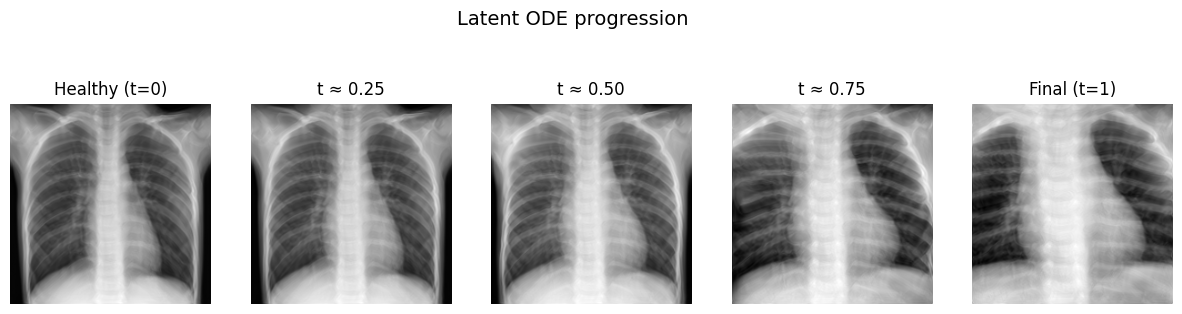

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))

for i, img in enumerate(decoded_images):

    plt.subplot(1, len(decoded_images), i+1)

    if i == 0:
        title = "Healthy (t=0)"
    elif i == len(decoded_images)-1:
        title = "Final (t=1)"
    else:
        title = f"t ≈ {time_indices[i]/80:.2f}"

    plt.title(title)
    plt.imshow(img[0,0], cmap="gray")
    plt.axis("off")

plt.suptitle("Latent ODE progression", fontsize=14)
plt.show()

### Guardar latents intermèdies

In [22]:
torch.save({
    "z0": z0_batch.cpu(),
    "trajectory": trajectories.cpu()
}, "generated_latent_trajectories.pt")

### EXTRA: Amb integrador RK4 + plot progressió



* Molt més estable
* Menys drift fora manifold
* Ideal per latents mètriques

In [23]:
def rk4_integration(vector_field,
                    z0,
                    n_steps=50,
                    t0=0.0,
                    t1=1.0):

    vector_field.eval()

    dt = (t1 - t0) / n_steps
    z = z0.clone().to(z0.device)

    trajectory = [z.detach().cpu()]

    for k in range(n_steps):

        t = torch.full((z.shape[0], 1),
                       t0 + k * dt,
                       device=z.device,
                       dtype=z.dtype)

        with torch.no_grad():

            k1 = vector_field(z, t)
            k2 = vector_field(z + 0.5 * dt * k1, t + 0.5 * dt)
            k3 = vector_field(z + 0.5 * dt * k2, t + 0.5 * dt)
            k4 = vector_field(z + dt * k3, t + dt)

        z = z + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

        trajectory.append(z.detach().cpu())

    return z, torch.stack(trajectory, dim=1)

### Escollim healthy real

In [24]:
# Escollim un latent healthy directament
healthy_indices = (labels == 0).nonzero(as_tuple=True)[0]
idx = healthy_indices[0]

z0 = latents[idx].unsqueeze(0).to(device)   # (1, 98)

print("z0 shape:", z0.shape)  # (1, 98)

z0 shape: torch.Size([1, 98])


### Tragectòria RK4

In [25]:
z_final, trajectory = rk4_integration(
    vector_field,
    z0,
    n_steps=80,
    t0=0.0,
    t1=1.0
)

print("Trajectory shape:", trajectory.shape) # (1, 81, 98)

Trajectory shape: torch.Size([1, 81, 98])


### Triem punts clau (agafem decoder Albert)

In [27]:
time_indices = [0, 20, 40, 60, 80]

decoded_images = []

with torch.no_grad():
    for t_idx in time_indices:
        z_t = trajectory[:, t_idx, :].to(device)
        img_t = autoencoder.decode(z_t)
        decoded_images.append(img_t.cpu())

### Plot progressió

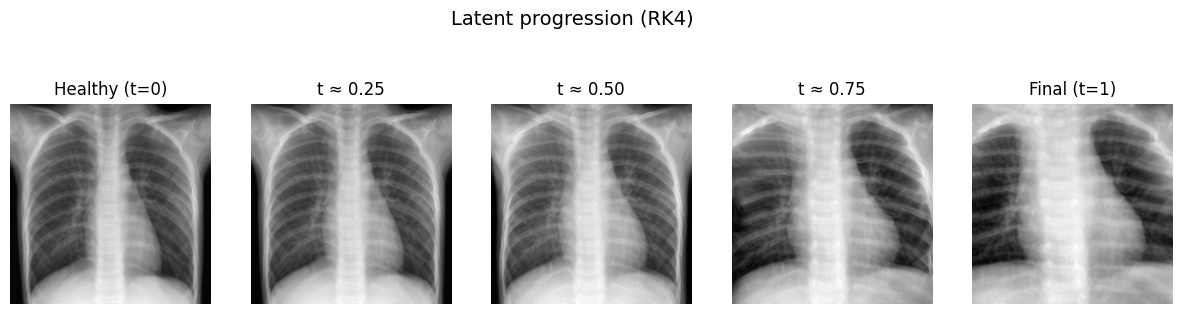

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))

for i, img in enumerate(decoded_images):

    plt.subplot(1, len(decoded_images), i+1)

    if i == 0:
        title = "Healthy (t=0)"
    elif i == len(decoded_images)-1:
        title = "Final (t=1)"
    else:
        title = f"t ≈ {time_indices[i]/80:.2f}"

    plt.title(title)
    plt.imshow(img[0,0], cmap="gray")
    plt.axis("off")

plt.suptitle("Latent progression (RK4)", fontsize=14)
plt.show()